In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [92]:
ucla_ground_truth = pd.read_excel('../data/ucla_ground_truth.xlsx', index_col=0)  
und_ground_truth = pd.read_excel('../data/und_ground_truth.xlsx', index_col=0)  
uvm_ground_truth = pd.read_excel('../data/uvm_ground_truth.xlsx', index_col=0)

ground_truth = pd.concat([ucla_ground_truth, und_ground_truth, uvm_ground_truth], ignore_index=True)
ground_truth.head(25)

,cat_type,start_yr,end_yr,page_num,col_num,type,annote_id,Department,Number,Title,Description,Prerequisites,Credits,Teacher,decade,quinquennium,DepartmentCleaned,combined_text,has_ai,is_not_course
0,both,1883,1884,26,0,courses,784005,Science,28,"Physiology, from skeleton and models, with law...",definition of terms; dimensions and motions; g...,NaN,0,"{'Honorific': '', 'Name': 'Normal School', 'De...",1880,1880,science,"Physiology, from skeleton and models, with law...",0,0
1,both,1883,1884,26,0,courses,784005,Language,28,Spelling,NaN,NaN,0,"{'Honorific': '', 'Name': 'Normal School', 'De...",1880,1880,language,Spelling,0,0
2,both,1883,1884,26,0,courses,784005,Middle Year,28,FIRST TERM.,NaN,NaN,0,"{'Honorific': '', 'Name': 'Normal School', 'De...",1880,1880,middle year,FIRST TERM.,0,1
3,both,1883,1884,26,0,courses,784005,Language,28,Rules of construction,Letter writing.,NaN,0,"{'Honorific': '', 'Name': 'Normal School', 'De...",1880,1880,language,Rules of construction Letter writing.,0,0
4,both,1883,1884,26,0,courses,784005,Science,28,"Physical Geography-A review of contour, and pr...",NaN,NaN,0,"{'Honorific': '', 'Name': 'Normal School', 'De...",1880,1880,science,"Physical Geography-A review of contour, and pr...",0,0
5,both,1883,1884,26,0,courses,784005,Language,28,Word analysis,NaN,NaN,0,"{'Honorific': '', 'Name': 'Normal School', 'De...",1880,1880,language,Word analysis,0,0
6,both,1883,1884,26,0,courses,784005,Miscellaneous,28,Reading and penmanship,"Penmanship, outline drawing, and reading.",NaN,0,"{'Honorific': '', 'Name': 'Normal School', 'De...",1880,1880,miscellaneous,"Reading and penmanship Penmanship, outline dra...",0,0
7,both,1883,1884,26,0,courses,784005,Professional,28,"For the first year, methods of teaching are im...",California Branch State,NaN,0,"{'Honorific': '', 'Name': 'Normal School', 'De...",1880,1880,professional,"For the first year, methods of teaching are im...",0,0
8,both,1883,1884,26,0,courses,784005,Language,27,"Spelling-Rules for spelling, and",Nature and power of letters; elementary sounds...,NaN,0,"{'Honorific': '', 'Name': 'Normal School', 'De...",1880,1880,language,"Spelling-Rules for spelling, and Nature and po...",0,0
9,both,1883,1884,26,0,courses,784005,Mathematics,28,Denominate numbers and mensurations,"Mental Arithmetic-Rapid operations, and simple...",NaN,0,"{'Honorific': '', 'Name': 'Normal School', 'De...",1880,1880,mathematics,Denominate numbers and mensurations Mental Ari...,0,0


In [93]:
df_course_level = pd.read_pickle('../data/selected_universities_course_level_embeddings.pkl')
df_course_level.info()
# reduced 4618936 to 896770 using embeddings - a diff of 3722166


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896770 entries, 0 to 896769
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ipeds_id               896770 non-null  object 
 1   cat_type               896770 non-null  object 
 2   start_yr               896770 non-null  int64  
 3   end_yr                 896770 non-null  int64  
 4   start_end_year         896770 non-null  object 
 5   Department             896770 non-null  object 
 6   DepartmentCleaned      896770 non-null  object 
 7   Number                 896770 non-null  object 
 8   Title                  896770 non-null  object 
 9   Description            896770 non-null  object 
 10  max_cos_similarity     896770 non-null  float32
 11  best_matching_keyword  896770 non-null  object 
dtypes: float32(1), int64(2), object(9)
memory usage: 78.7+ MB


In [94]:
merge_cols = ['cat_type', 'start_yr', 'end_yr', 'Department', 'Number', 'Title']

# Merge the dataframes
eval_df = ground_truth.merge(
    df_course_level[merge_cols + ['max_cos_similarity', 'best_matching_keyword']],
    on=merge_cols,
    how='left'  # or 'left' to keep all ground truth entries
)

In [95]:
# Filter to courses only
courses_df = eval_df[eval_df['is_not_course'] == 0].copy()
courses_df['max_cos_similarity'] = courses_df['max_cos_similarity'].fillna(0)


total_ai = courses_df['has_ai'].sum()
total_non_ai = (courses_df['has_ai'] == 0).sum()

print(f"Ground Truth: {total_ai} AI courses, {total_non_ai} non-AI courses")
print("\n" + "="*70)
print(f"{'Threshold':<12} {'Total':<10} {'AI':<10} {'Non-AI':<10}")
print("="*70)

for threshold in [0.1 * i for i in range(11)]:
    matched = courses_df[courses_df['max_cos_similarity'] >= threshold]
    
    ai_count = matched['has_ai'].sum()
    non_ai_count = (matched['has_ai'] == 0).sum()
    total = len(matched)
    
    print(f"{threshold:<12.1f} {total:<10d} {ai_count:<10d} {non_ai_count:<10d}")

Ground Truth: 7 AI courses, 2962 non-AI courses

Threshold    Total      AI         Non-AI    
0.0          2969       7          2962      
0.1          2842       7          2835      
0.2          1645       7          1638      
0.3          444        7          437       
0.4          101        7          94        
0.5          31         4          27        
0.6          7          1          6         
0.7          1          0          1         
0.8          0          0          0         
0.9          0          0          0         
1.0          0          0          0         


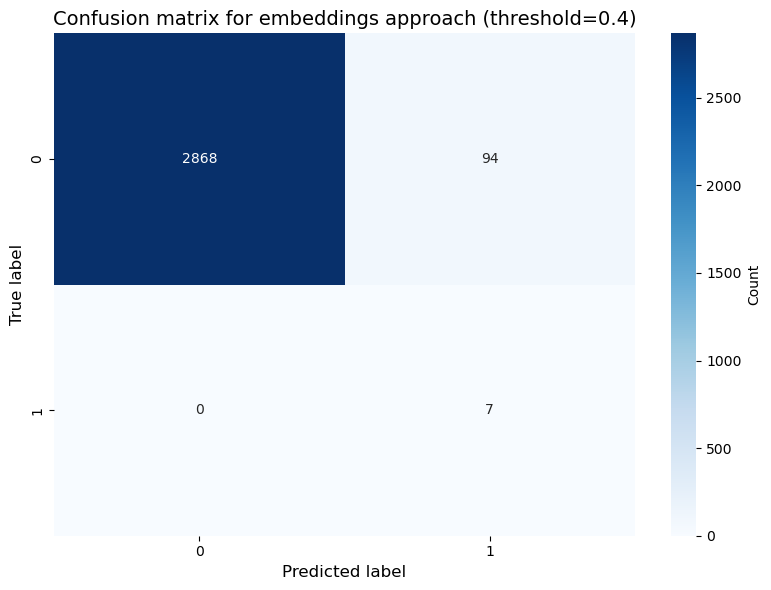


Confusion Matrix:
True Negatives (Non-AI correctly identified): 2868
False Positives (Non-AI incorrectly flagged): 94
False Negatives (AI courses missed): 0
True Positives (AI correctly identified): 7

Recall: 100.0%
Precision: 6.9%
False Positive Rate: 3.2%


In [96]:
courses_df['predicted_ai'] = (courses_df['max_cos_similarity'] >= 0.4).astype(int)

cm = confusion_matrix(courses_df['has_ai'], courses_df['predicted_ai'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['0', '1'], 
            yticklabels=['0', '1'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)
plt.title('Confusion matrix for embeddings approach (threshold=0.4)', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_embeddings.png', dpi=300, bbox_inches='tight')  # Save to current directory
plt.show()

print("\nConfusion Matrix:")
print(f"True Negatives (Non-AI correctly identified): {cm[0,0]}")
print(f"False Positives (Non-AI incorrectly flagged): {cm[0,1]}")
print(f"False Negatives (AI courses missed): {cm[1,0]}")
print(f"True Positives (AI correctly identified): {cm[1,1]}")

recall = cm[1,1] / (cm[1,0] + cm[1,1]) * 100
precision = cm[1,1] / (cm[0,1] + cm[1,1]) * 100
fpr = cm[0,1] / (cm[0,0] + cm[0,1]) * 100

print(f"\nRecall: {recall:.1f}%")
print(f"Precision: {precision:.1f}%")
print(f"False Positive Rate: {fpr:.1f}%")